# 01 - Looking at the data

**Start here.** Before any model, we look at what we actually have.

Run `python -m ecg.build_dataset` first if `data/build/` is empty.

Every example is **one heartbeat**, taken out of a 30 minute ECG recording and
labelled by a cardiologist:

| class | what it is |
|---|---|
| **N** | a normal beat |
| **S** | starts early, from the top of the heart. The **shape looks normal** |
| **V** | starts in the bottom of the heart. Wide, slurred shape |
| **F** | two beats collided. The shape is between N and V |

In [1]:
%load_ext autoreload
%autoreload 2

import collections
import numpy as np
import matplotlib.pyplot as plt

from ecg.data import load_split, class_names, splits
from ecg.metrics import macro_f1, majority_baseline, report
from ecg import plots

CLASSES = class_names("all")
print("classes:", CLASSES)

classes: ['N', 'S', 'V', 'F']


## 1. What one example looks like

Two blocks of numbers per beat:

- **250 numbers**: the voltage, one every 1/360 of a second, from 0.25 s before the
  peak to 0.44 s after it
- **4 numbers**: the timing. How early or late this beat arrived, compared to that
  same patient's usual rhythm

In [2]:
X, y, rec = load_split("train", features="waveform+rr")
print("X:", X.shape, " y:", y.shape, " patient id:", rec.shape)
print()

i = 5000
print("one beat, row", i)
print("   from patient :", rec[i])
print("   label        :", y[i], "->", CLASSES[y[i]])
print("   waveform     :", np.round(X[i][:6], 2), "...", np.round(X[i][244:250], 2))
print("   peak value   : %.2f at index %d (the R peak sits at index 90)"
      % (X[i][:250].max(), X[i][:250].argmax()))
print("   timing       :", np.round(X[i][250:], 3),
      " <- pre_rr, post_rr, local_rr, pre/local")

X: (40496, 254)  y: (40496,)  patient id: (40496,)

one beat, row 5000
   from patient : 109
   label        : 0 -> N
   waveform     : [0.39 0.37 0.37 0.38 0.32 0.24] ... [0.35 0.33 0.35 0.37 0.42 0.45]
   peak value   : 3.44 at index 88 (the R peak sits at index 90)
   timing       : [1.056 1.028 1.023 1.032]  <- pre_rr, post_rr, local_rr, pre/local


The last timing number is the useful one. It is **this gap divided by the patient's
usual gap**:

- **= 1.0** the beat arrived on time
- **< 1.0** it arrived early

## 2. How many of each class, and the floor

In [3]:
print("%-6s %9s %8s %7s %7s %6s %11s %10s"
      % ("split", "patients", "N", "S", "V", "F", "accuracy", "macro-F1"))
for sp in ["train", "dev", "test"]:
    X_, y_, rec_ = load_split(sp, classes="all")
    c = np.bincount(y_, minlength=4)
    lazy = np.zeros_like(y_)
    print("%-6s %9d %8d %7d %7d %6d %11.4f %10.4f"
          % (sp, len(set(rec_.tolist())), c[0], c[1], c[2], c[3],
             majority_baseline(y_, 4), macro_f1(y_, lazy, 4)))
print()
print("the last two columns are what you get by ALWAYS saying 'normal'.")

split   patients        N       S       V      F    accuracy   macro-F1


train         17    36418     726    2970    382      0.8993     0.2367
dev            5     9430     218     818     32      0.8983     0.2366


test          22    44240    1837    3220    388      0.8904     0.2355

the last two columns are what you get by ALWAYS saying 'normal'.


Look at those two columns.

A model that learns nothing and always answers "normal" gets about **89% accuracy**.
That is why accuracy is not a useful score here. Its macro-F1 is only **0.24**, and
that number tells the truth, because it averages the four classes equally and three
of them get zero.

**Macro-F1 is the score we use in this project. The floor is about 0.236.**

## 3. The most important thing about the split

The three splits contain **different patients**. No patient appears in two of them.

In [4]:
s = splits()
for name in ["train", "dev", "test"]:
    print("%-6s %2d patients: %s" % (name, len(s[name]), " ".join(s[name])))
print()
print("train and dev share a patient:", bool(set(s["train"]) & set(s["dev"])))
print("train and test share a patient:", bool(set(s["train"]) & set(s["test"])))
print("dev and test share a patient:", bool(set(s["dev"]) & set(s["test"])))

train  17 patients: 101 106 109 112 114 115 116 118 119 122 201 203 208 209 215 220 230
dev     5 patients: 108 124 205 207 223
test   22 patients: 100 103 105 111 113 117 121 123 200 202 210 212 213 214 219 221 222 228 231 232 233 234

train and dev share a patient: False
train and test share a patient: False
dev and test share a patient: False


In [5]:
X_, y_, rec_ = load_split("train", classes="all")
counts = collections.Counter(rec_.tolist())
n = np.array(sorted(counts.values()))
print("beats per patient in train: min %d, median %d, max %d" % (n.min(), int(np.median(n)), n.max()))
print()
print("this is why the split matters. one patient gives us about %d beats," % np.median(n))
print("and they all come from the same heart, so they look almost the same.")
print("if we split the BEATS at random instead of the PATIENTS, then almost every")
print("test beat would have a near twin sitting in the training set, and the model")
print("could score very high just by recognising people.")

beats per patient in train: min 1862, median 2277, max 3362

this is why the split matters. one patient gives us about 2277 beats,
and they all come from the same heart, so they look almost the same.
if we split the BEATS at random instead of the PATIENTS, then almost every
test beat would have a near twin sitting in the training set, and the model
could score very high just by recognising people.


## 4. What the four classes look like

Now the interesting part. Here is the average beat of each class.

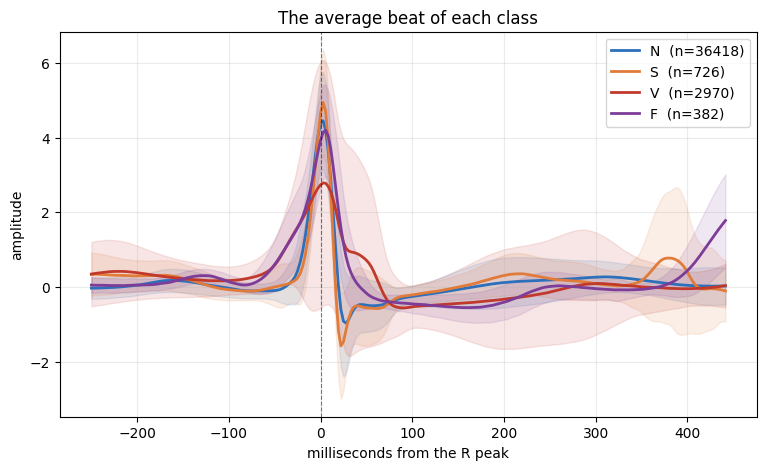

In [6]:
X_, y_, rec_ = load_split("train", features="waveform")
t = plots.beat_time_axis(250)

fig, ax = plt.subplots(figsize=(9, 5))
for i, c in enumerate(CLASSES):
    w = X_[y_ == i]
    m, sd = w.mean(axis=0), w.std(axis=0)
    ax.plot(t, m, color=plots.CLASS_COLOURS[c], lw=2, label="%s  (n=%d)" % (c, len(w)))
    ax.fill_between(t, m - sd, m + sd, color=plots.CLASS_COLOURS[c], alpha=0.12)
ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("milliseconds from the R peak")
ax.set_ylabel("amplitude")
ax.set_title("The average beat of each class")
ax.legend(); ax.grid(alpha=0.25)
plt.show()

Read the shapes.

- **N** is a narrow, sharp spike. The signal used the heart's fast wiring.
- **V** is low and wide. It started in the bottom of the heart and had to crawl
  through muscle instead, so the squeeze is slow and spread out.
- **F** sits **between N and V**. That is exactly what a fusion beat is, and we did
  not tell the model that. It fell out of the data.
- **S** is almost the same shape as **N**. This is the whole problem of the project.

## 5. So how do we ever find class S?

By **when** it arrives, not what it looks like. Here is the timing feature.

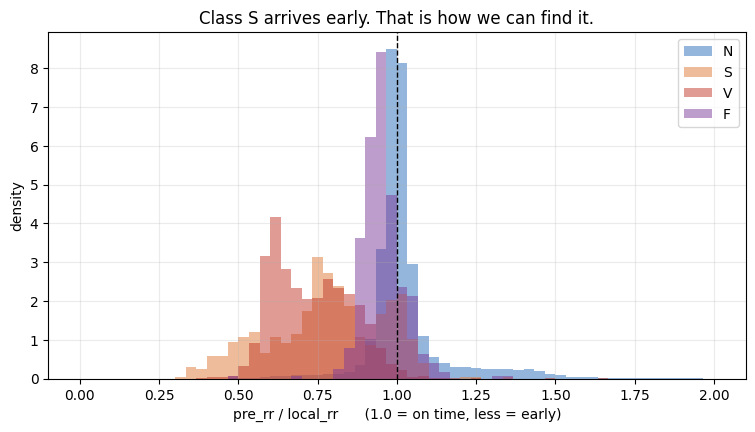

median value of that ratio:
   N: 1.002
   S: 0.784
   V: 0.720
   F: 0.951


In [7]:
X_, y_, _ = load_split("train", features="rr")
ratio = X_[:, 3]

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, c in enumerate(CLASSES):
    ax.hist(ratio[y_ == i], bins=60, range=(0, 2), density=True,
            color=plots.CLASS_COLOURS[c], alpha=0.5, label=c)
ax.axvline(1.0, color="k", lw=1, ls="--")
ax.set_xlabel("pre_rr / local_rr      (1.0 = on time, less = early)")
ax.set_ylabel("density")
ax.set_title("Class S arrives early. That is how we can find it.")
ax.legend(); ax.grid(alpha=0.25)
plt.show()

print("median value of that ratio:")
for i, c in enumerate(CLASSES):
    print("   %s: %.3f" % (c, np.median(ratio[y_ == i])))

**N sits at 1.00. S sits at 0.78.** So S beats really do arrive early, and the model
can use that.

But look again: **V sits at 0.72**, which is also early. So timing alone says "this
beat came too soon" without saying which kind it is. Telling S from V needs the
shape as well as the timing. That turns out to be the single most important fact in
this project, and notebook `08` is where it catches us out.

## 6. The rare classes live inside very few patients

In [8]:
X_, y_, rec_ = load_split("train", classes="all")
print("how many training patients actually have beats of each class?")
print()
for i, c in enumerate(CLASSES):
    per = collections.Counter(rec_[y_ == i].tolist())
    big = [(v, k) for k, v in per.items() if v >= 20]
    big.sort(reverse=True)
    print("   %s: %2d patients with 20 or more   %s"
          % (c, len(big), "  ".join("%s:%d" % (k, v) for v, k in big[:5])))

how many training patients actually have beats of each class?

   N: 17 patients with 20 or more   215:3194  209:2620  112:2536  203:2529  109:2491
   S:  4 patients with 20 or more   209:383  201:128  118:96  220:94
   V:  9 patients with 20 or more   208:992  106:520  203:444  119:444  201:198
   F:  1 patients with 20 or more   208:372


This is the quiet problem in the whole dataset.

Class **F** exists in the training set, but **one patient has almost all of it**. So
the model can never really learn "what a fusion beat looks like", only "what patient
208's fusion beats look like". Its F1 stays at **0.000** in every experiment we run,
and that is a fact about the data, not about the model.

Class **S** is not much better off.

> **A class measured on one or two people tells you about those people, not about
> the class.**

We did not fully take that lesson at the start, and it cost us. See notebook `08`.

## 7. Some real beats

Finally, individual beats rather than averages, so you can see how noisy real data is.

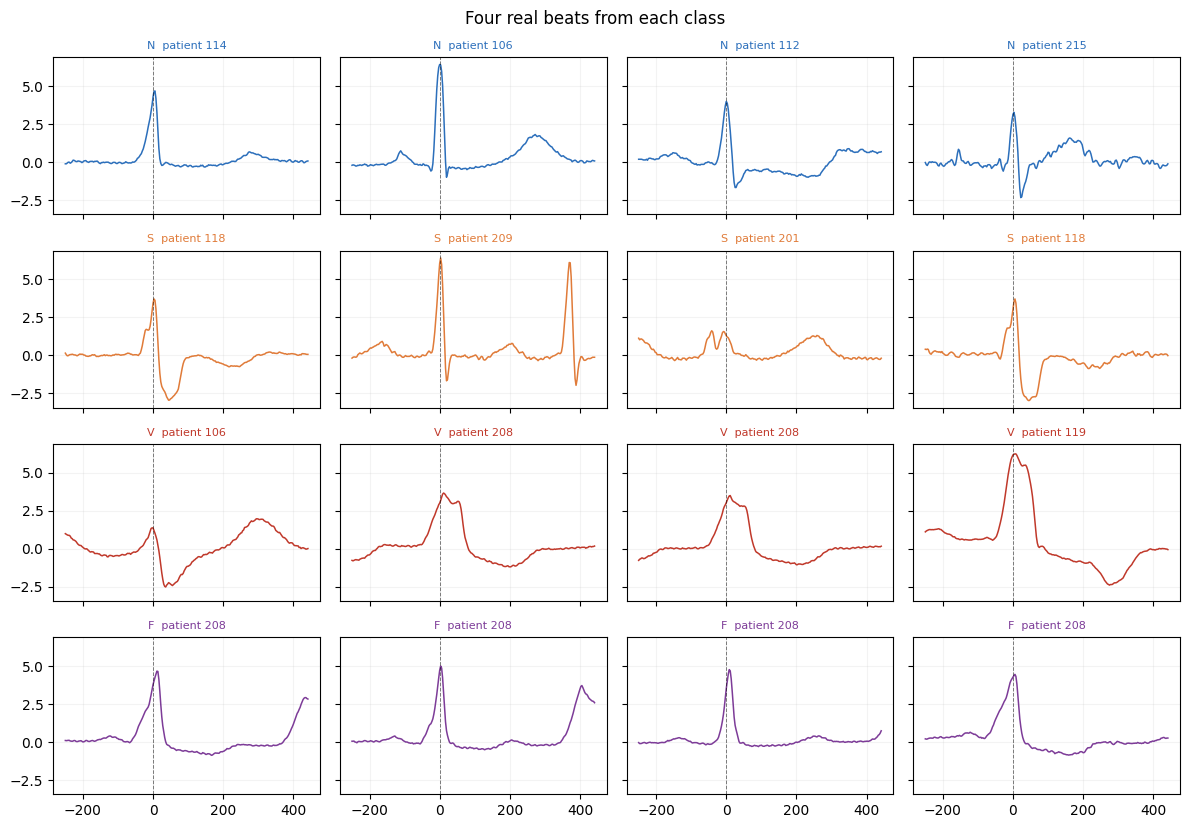

In [9]:
X_, y_, rec_ = load_split("train", features="waveform")
rng = np.random.default_rng(3)
rows, labels = [], []
for i, c in enumerate(CLASSES):
    idx = rng.choice(np.where(y_ == i)[0], 4, replace=False)
    rows.extend(X_[idx])
    labels.extend("%s  patient %s" % (c, rec_[j]) for j in idx)

fig = plots.beats(np.array(rows), labels, ncols=4,
                  title="Four real beats from each class")
plt.show()

## What to read next

| notebook | |
|---|---|
| `02_logistic_regression` | one neuron, written from scratch and checked against scikit-learn |
| `03_shallow_nn` | one hidden layer, and why we always run three seeds |
| `04_deep_nn_gradcheck` | a network of any depth, and how to prove the gradient is right |
| `05_softmax_multiclass` | all four classes at once |
| `06_ablations` | which of the C2 tricks actually change anything |
| `07_batchnorm` | batch norm, and why it cannot replace scaling the input |
| `08_error_analysis` | the test set, and how our dev set chose the wrong model |
| `09_pytorch` | the same network in PyTorch, agreeing to 1e-17 |